# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
A model is linear if it is linear in the coefficients
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?) 
A dummy variable coefficient shows how much the outcome changes compared to the reference group, which is captured by the intercept.
3. Can linear regression be used for classification? Explain why, or why not.
Linear regression is not useful for classification because it doesnt represent probabilities that good. Predictions can fall below 0 or above 1 and that isn't ideal. 
4. What are signs that your linear model is over-fitting?
When the model fits training data well but test data poorly.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
It means when predicting varriables are correlated and it is hard to differentiate their effects which causes unstable coefficients.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
You can add logarithms, squared terms, etc.
7. What is the interpretation of the slope coefficient in a linear regression?
The slope represents a how much y is increased/decreased corresponding to when x changes.
8.  Compare the train/test split and $k$-fold cross validation.
Train/test split uses one split where it divides the data into two parts. k-fold cross validation repeatedly splits data into different parts to evaluate the models better.
9.  How is the $k$ in $k$-fold cross validation typically selected?
it is usually chosen as 5 or 10 to best balance the accuracy.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

df = pd.read_csv('./data/Q1_clean.csv')
df = df.rename(columns={'Review Scores Rating': 'Review_Scores_Rating'})
df.columns = df.columns.str.strip().str.lower()
df.head()

,price,review_scores_rating,neighbourhood,property type,room type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


## 1)

In [70]:
avg_table = df.groupby('neighbourhood')[['price', 'review_scores_rating']].mean()
print(avg_table)

print("Most expensive:", avg_table['price'].idxmax())

                    price  review_scores_rating
neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive: Manhattan


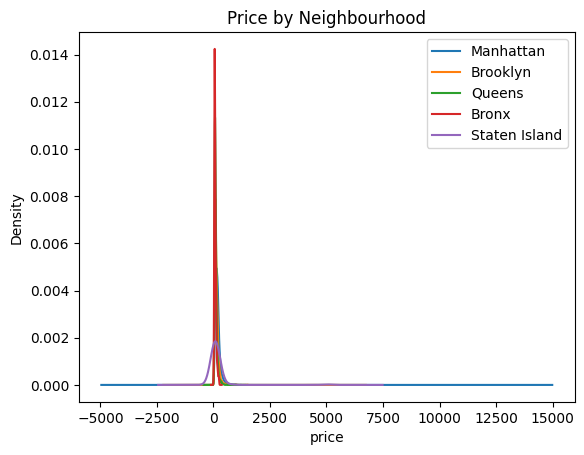

In [71]:
for area in df['neighbourhood'].unique():
    df[df['neighbourhood'] == area]['price'].plot.kde(label=area)

plt.xlabel('price')
plt.title('Price by Neighbourhood')
plt.legend()
plt.show()

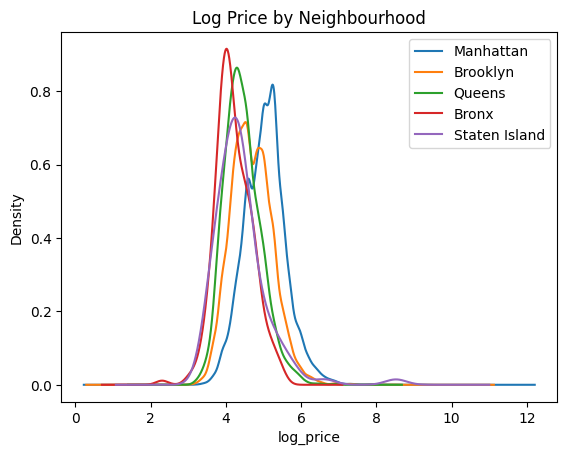

In [72]:
df['log_price'] = np.log(df['price'])

for area in df['neighbourhood'].unique():
    df[df['neighbourhood'] == area]['log_price'].plot.kde(label=area)

plt.xlabel('log_price')
plt.title('Log Price by Neighbourhood')
plt.legend()
plt.show()

The price distribution was bad because of outlying values. After using the log transformation, we can see that Manhattan is the most expensive place on average.

## 2)

In [73]:
X = pd.get_dummies(df['neighbourhood'], drop_first=True)
y = df['price']

model1 = LinearRegression()
model1.fit(X, y)

print("Intercept:", model1.intercept_)
print("Coefficients:", model1.coef_)
print("Columns:", X.columns)

Intercept: 75.27649769584667
Coefficients: [ 52.47088065 108.38778863  21.58073501  70.89016897]
Columns: Index(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='object')


The intercept is the mean price for the reference neighborhood, and each dummy coefficient shows the difference from that group. The regression coefficients are directly related to the group means from part 1.

## 3)

In [74]:
X = df[['review_scores_rating']]
y = df['price']

model2 = LinearRegression()
model2.fit(X, y)

print("Intercept:", model2.intercept_)
print("Slope:", model2.coef_[0])

Intercept: 60.878390657123816
Slope: 1.0208266022674735


The slope shows that for every 1-point increase in review score, the price increases by about $1.02 on average. This means higher-rated listings tend to have higher prices.

## 4)

In [75]:
X = pd.concat([
    df[['review_scores_rating']],
    pd.get_dummies(df['neighbourhood'], drop_first=True)
], axis=1)

y = df['price']

model3 = LinearRegression()
model3.fit(X, y)

coef_table3 = pd.DataFrame({
    'variable': ['intercept'] + list(X.columns),
    'coefficient': [model3.intercept_] + list(model3.coef_)
})
print(coef_table3)

               variable  coefficient
0             intercept   -23.812561
1  review_scores_rating     1.081116
2              Brooklyn    51.704240
3             Manhattan   108.228737
4                Queens    21.694600
5         Staten Island    71.766552


Higher review scores slightly increase price. Compared to the reference neighborhood, Manhattan is the most expensive, followed by Staten Island, Brooklyn, and Queens.

## 5)

In [76]:
dummies = pd.get_dummies(df['neighbourhood'], drop_first=True)

X = pd.concat([df[['review_scores_rating']], dummies], axis=1)

for col in dummies.columns:
    X[col + '_x_rating'] = dummies[col] * df['review_scores_rating']

y = df['price']

model4 = LinearRegression()
model4.fit(X, y)

coef_table4 = pd.DataFrame({
    'variable': ['intercept'] + list(X.columns),
    'coefficient': [model4.intercept_] + list(model4.coef_)
})
print(coef_table4)

                 variable  coefficient
0               intercept    22.638385
1    review_scores_rating     0.574311
2                Brooklyn   -16.392990
3               Manhattan    41.315429
4                  Queens    28.259701
5           Staten Island  2963.071040
6       Brooklyn_x_rating     0.741165
7      Manhattan_x_rating     0.729703
8         Queens_x_rating    -0.072294
9  Staten Island_x_rating   -31.831748


This model shows the effect of the review score being different in each neighborhood. Some neughborhoods have similar slopes, while other vary greatly. This shows that the relationship between rating and price is not the same

## 6)

In [77]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
y = df['price']

Part 3

In [78]:
X1 = df[['review_scores_rating']]
cv1 = cross_val_score(LinearRegression(), X1, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 1 CV MSE:", -cv1.mean())

Model 1 CV MSE: 22078.215444464753


Part 4

In [79]:
X2 = pd.concat([
    df[['review_scores_rating']],
    pd.get_dummies(df['neighbourhood'], drop_first=True)
], axis=1)

cv2 = cross_val_score(LinearRegression(), X2, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 2 CV MSE:", -cv2.mean())

Model 2 CV MSE: 21068.500019790667


Part 5

In [80]:
dummies = pd.get_dummies(df['neighbourhood'], drop_first=True)

X3 = pd.concat([df[['review_scores_rating']], dummies], axis=1)

for col in dummies.columns:
    X3[col + '_x_rating'] = dummies[col] * df['review_scores_rating']

cv3 = cross_val_score(LinearRegression(), X3, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 3 CV MSE:", -cv3.mean())

Model 3 CV MSE: 21293.768998593343


Since model 2 has the lowest CV MSE, it performs best on new data. 

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [81]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
df = pd.read_csv('./data/cars_hw.csv')
df.columns = df.columns.str.strip().str.lower()
df.head()

,unnamed: 0,make,make_year,color,body_type,mileage_run,no_of_owners,seating_capacity,fuel_type,transmission,transmission_type,price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


## 1)

In [82]:
print(df['price'].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: price, dtype: float64


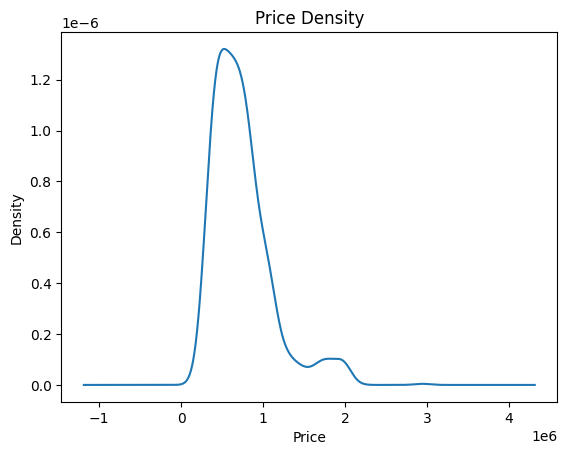

In [83]:
df['price'].plot.kde()
plt.title('Price Density')
plt.xlabel('Price')
plt.show()

In [84]:
print(df.groupby('body_type')['price'].describe())

           count          mean            std       min       25%        50%  \
body_type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
body_type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


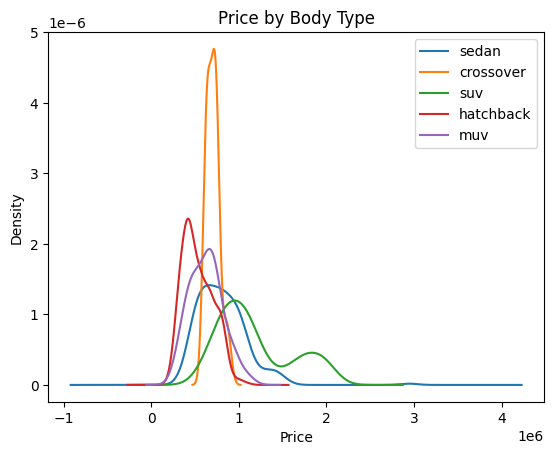

In [85]:
for b in df['body_type'].dropna().unique():
    df[df['body_type'] == b]['price'].plot.kde(label=b)

plt.title('Price by Body Type')
plt.xlabel('Price')
plt.legend()
plt.show()

Most variance: SUV
Most Expensive: SUV

## 2)

In [86]:
X = df[['seating_capacity']]
y = df['price']

model = LinearRegression().fit(X, y)

print("Slope:", model.coef_[0])

Slope: 59267.9980367217


Price changes about 60000

In [87]:
X = pd.get_dummies(df['seating_capacity'], drop_first=True)
y = df['price']

model = LinearRegression().fit(X, y)

print(model.coef_)

[ 546483.87096774 1456000.          735948.71794872  271800.        ]


## 3)

In [88]:
df['age'] = 2025 - df['make_year']

In [89]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)
y = df['price']

for d in range(1, 6):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    scores = cross_val_score(model, df[['age']], y, cv=kf, scoring='neg_mean_squared_error')
    print("Degree", d, "MSE:", -scores.mean())

Degree 1 MSE: 97745760011.44075
Degree 2 MSE: 97815319552.31636
Degree 3 MSE: 97304076284.3857
Degree 4 MSE: 96785385468.5754
Degree 5 MSE: 95816293469.88058


In [90]:
best_degree = cv_table.loc[cv_table['cv_mse'].idxmin(), 'degree']
print("Best degree:", best_degree)

Best degree: 5


Write up

## 4)

In [91]:
model = make_pipeline(PolynomialFeatures(2), LinearRegression())  # change 2 if needed
model.fit(df[['age']], df['price'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


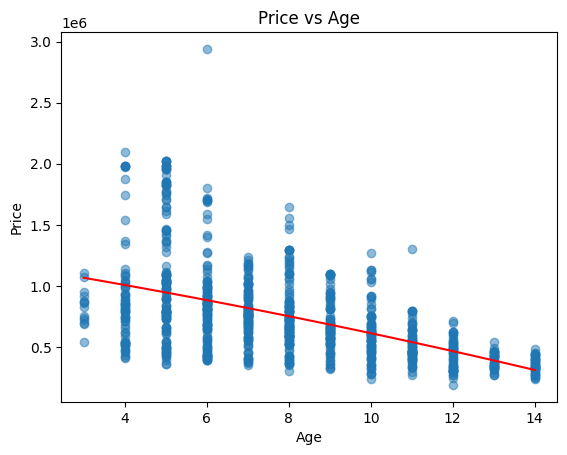

In [92]:
age_vals = np.linspace(df['age'].min(), df['age'].max(), 100)
pred = model.predict(age_vals.reshape(-1, 1))

plt.scatter(df['age'], df['price'], alpha=0.5)
plt.plot(age_vals, pred, color='red')

plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age')
plt.show()

It does not fit well

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

df = pd.read_csv('./data/heart_hw.csv')
df.columns = df.columns.str.strip().str.lower()
df.head()

,unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


## 1)

In [94]:
survival_rates = df.groupby('transplant')['y'].mean()
print(survival_rates)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64


In [95]:
control_rate = survival_rates['control']
treatment_rate = survival_rates['treatment']
ate = treatment_rate - control_rate

print("Control survival rate:", control_rate)
print("Treatment survival rate:", treatment_rate)
print("ATE:", ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


The control survival rate is about 0.12, and the treatment survival rate is about 0.35. The ATE is about 0.23, meaning people who got a transplant were more likely to survive.

## 2)

In [96]:
df['transplant_dummy'] = (df['transplant'] == 'treatment').astype(int)

In [97]:
X = df[['transplant_dummy']]
y = df['y']

model1 = LinearRegression()
model1.fit(X, y)

print("Intercept:", model1.intercept_)
print("Transplant coefficient:", model1.coef_[0])

Intercept: 0.11764705882352941
Transplant coefficient: 0.23017902813299232


The intercept (0.12) is the survival rate for the control group. The transplant coefficient (0.23) shows how much higher the survival rate is for people who received a transplant.

In [98]:
X = df[['transplant_dummy', 'age']]
y = df['y']

model2 = LinearRegression()
model2.fit(X, y)

print("Intercept:", model2.intercept_)
print("Coefficients:", model2.coef_)
print("Columns:", X.columns)

Intercept: 0.7019569721740946
Coefficients: [ 0.26470169 -0.01360722]
Columns: Index(['transplant_dummy', 'age'], dtype='object')


## 3)

In [100]:
age_vals = np.linspace(df['age'].min(), df['age'].max(), 100)

control_pred = model2.predict(pd.DataFrame({
    'transplant_dummy': 0,
    'age': age_vals
}))

treat_pred = model2.predict(pd.DataFrame({
    'transplant_dummy': 1,
    'age': age_vals
}))

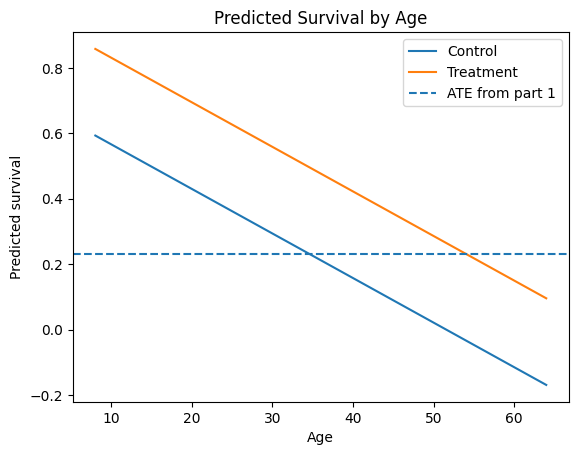

In [101]:
plt.plot(age_vals, control_pred, label='Control')
plt.plot(age_vals, treat_pred, label='Treatment')
plt.axhline(ate, linestyle='--', label='ATE from part 1')

plt.xlabel('Age')
plt.ylabel('Predicted survival')
plt.title('Predicted Survival by Age')
plt.legend()
plt.show()

Survival goes down as age increases. The treatment group always has higher survival. 

## 4)

In [102]:
df['transplant_age'] = df['transplant_dummy'] * df['age']

In [103]:
X = df[['transplant_dummy', 'age', 'transplant_age']]
y = df['y']

model3 = LinearRegression()
model3.fit(X, y)

print("Intercept:", model3.intercept_)
print("Coefficients:", model3.coef_)
print("Columns:", X.columns)

Intercept: 0.35486517529945866
Coefficients: [ 0.90775139 -0.00552426 -0.01459064]
Columns: Index(['transplant_dummy', 'age', 'transplant_age'], dtype='object')


In [104]:
control_pred2 = model3.predict(pd.DataFrame({
    'transplant_dummy': 0,
    'age': age_vals,
    'transplant_age': 0
}))

treat_pred2 = model3.predict(pd.DataFrame({
    'transplant_dummy': 1,
    'age': age_vals,
    'transplant_age': age_vals
}))

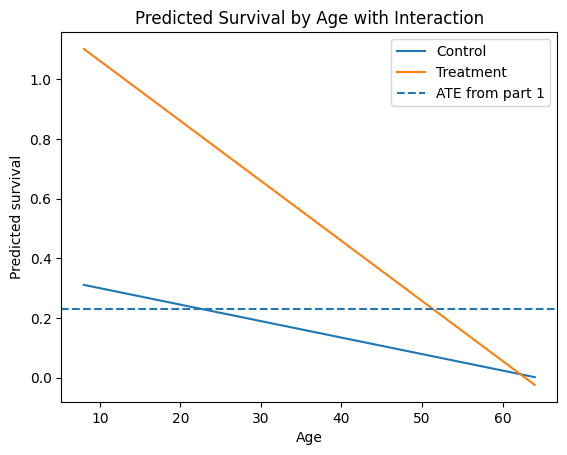

In [105]:
plt.plot(age_vals, control_pred2, label='Control')
plt.plot(age_vals, treat_pred2, label='Treatment')
plt.axhline(ate, linestyle='--', label='ATE from part 1')

plt.xlabel('Age')
plt.ylabel('Predicted survival')
plt.title('Predicted Survival by Age with Interaction')
plt.legend()
plt.show()

With the interaction, the transplant effect changes with age. It helps more for younger people and less for older people.

## 5)

In [106]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)
y = df['y']

In [107]:
X1 = df[['transplant_dummy']]
cv1 = cross_val_score(LinearRegression(), X1, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 1 CV MSE:", -cv1.mean())

Model 1 CV MSE: 0.19497249586192153


In [108]:
X2 = df[['transplant_dummy', 'age']]
cv2 = cross_val_score(LinearRegression(), X2, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 2 CV MSE:", -cv2.mean())

Model 2 CV MSE: 0.17926415954952163


In [109]:
X3 = df[['transplant_dummy', 'age', 'transplant_age']]
cv3 = cross_val_score(LinearRegression(), X3, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 3 CV MSE:", -cv3.mean())

Model 3 CV MSE: 0.1788020676251734


Model 3 has the lowest CV MSE, so it predicts best. Adding age improves the model, and adding the interaction improves it slightly more.

## 6)

The model is too simple and that is not good when it comes to medical matters.